# Supplementary Figure S4(C) — Per-class priority-review fraction

Percent of each LW class below 75, curated vs lower-quality.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_ROOT = Path.cwd().parent.parent
FIGURES = _ROOT / "figures"

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / name

In [2]:
LW = ["cWW", "tWW", "cWH", "tWH", "cWS", "tWS", "cHH", "tHH", "cHS", "tHS", "cSS", "tSS"]


CUT = 75


GOOD_C, ALL_C, POOR_C = "#2ca02c", "#1f77b4", "#d62728"


def scored_pairs(lw_only=True):
    """Unambiguous, scored per-pair records. lw_only keeps the 12 canonical LW classes."""
    raw = pd.DataFrame(json.loads(l) for l in open(data_file("reference/scores/pair_scores_uniques_parse.jsonl")))
    df = raw[~raw["is_ambiguous"] & raw["score"].notna()].copy()
    if lw_only:
        df = df[df["lw_class"].isin(LW)].copy()
    return df


def good_poor_sets():
    good = set(json.load(open(data_file("reference/reference_sets/reference_set.json")))["pdbs"])
    poor = set(json.load(open(data_file("reference/reference_sets/reference_set_poor.json")))["pdbs"])
    return good, poor


def split_good_poor(df):
    """Return (df_good, df_poor) subsets by curated / lower-quality PDB membership."""
    good, poor = good_poor_sets()
    u = df["pdb_id"].str.upper()
    return df[u.isin(good)], df[u.isin(poor)]

saved figures/figS4_C_fraction_below_75_by_class.png


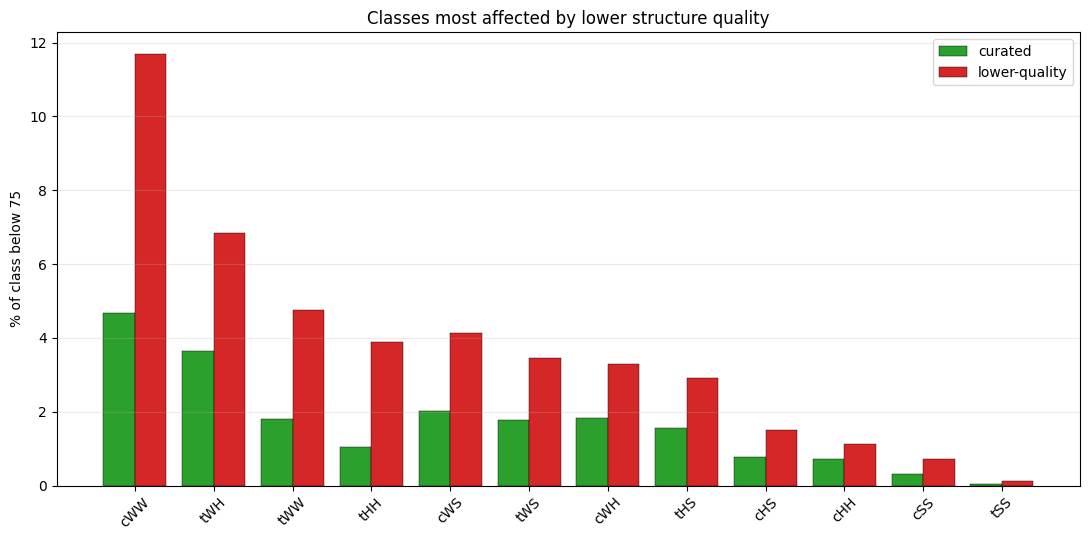

In [3]:
df = scored_pairs(lw_only=True)
df_good, df_poor = split_good_poor(df)
present = [c for c in LW if (df_good['lw_class'] == c).sum() >= 5
                          and (df_poor['lw_class'] == c).sum() >= 5]
gv = {c: 100*np.mean(df_good.loc[df_good['lw_class'] == c, 'score'].values < CUT) for c in present}
pv = {c: 100*np.mean(df_poor.loc[df_poor['lw_class'] == c, 'score'].values < CUT) for c in present}
order = sorted(present, key=lambda c: pv[c]-gv[c], reverse=True)
xc = np.arange(len(order)); w = 0.4
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(xc-w/2, [gv[c] for c in order], w, color=GOOD_C, edgecolor='k', lw=0.3, label='curated')
ax.bar(xc+w/2, [pv[c] for c in order], w, color=POOR_C, edgecolor='k', lw=0.3, label='lower-quality')
ax.set_xticks(xc); ax.set_xticklabels(order, rotation=45)
ax.set_ylabel('% of class below 75')
ax.set_title('Classes most affected by lower structure quality')
ax.legend(); ax.grid(alpha=0.25, axis='y')
fig.tight_layout(); print('saved', savefig(fig, 'figS4_C_fraction_below_75_by_class.png')); plt.show()